In [8]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv(r"C:\Users\hp\Downloads\archive (2)\customer_segmentation.csv")

print(df.shape)
df.info()
df.isnull().sum()

(2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
# Drop rows with missing Income (only 24 out of 2240 — safe to drop)
df = df.dropna(subset=['Income'])

# Remove the Income outlier(s) — cap using a sensible upper bound
df = df[df['Income'] < 200000]

# Fix Year_Birth — remove implausible birth years (customers older than ~100)
df = df[df['Year_Birth'] > 1930]
df['Age'] = 2014 - df['Year_Birth']  # dataset is from ~2014, based on Dt_Customer range

# Clean Marital_Status — fold nonsense categories into 'Single' or drop them
df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single'})

# Drop constant/useless columns
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

# Convert Dt_Customer to real datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

print(df.shape)  # check how many rows remain after cleaning
df.describe()

(2208, 28)


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
count,2208.00,2208.00,2208.00,2208.00,2208.00,2208,2208.00,2208.00,2208.00,2208.00,...,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00
mean,5584.53,1968.90,51943.52,0.44,0.51,2013-07-10 12:50:13.043478272,49.06,305.23,26.30,167.00,...,5.81,5.32,0.07,0.07,0.07,0.06,0.01,0.01,0.15,45.10
min,0.00,1940.00,1730.00,0.00,0.00,2012-07-30 00:00:00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.00
25%,2814.75,1959.00,35196.00,0.00,0.00,2013-01-16 00:00:00,24.00,24.00,1.75,16.00,...,3.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.00
50%,5454.50,1970.00,51371.00,0.00,0.00,2013-07-08 12:00:00,49.00,174.00,8.00,68.00,...,5.00,6.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.00
75%,8418.50,1977.00,68487.00,1.00,1.00,2013-12-31 00:00:00,74.00,505.50,33.00,232.25,...,8.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,55.00
max,11191.00,1996.00,162397.00,2.00,2.00,2014-06-29 00:00:00,99.00,1493.00,199.00,1725.00,...,13.00,20.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,74.00
std,3246.08,11.70,21536.76,0.54,0.54,NaN,28.94,337.61,39.73,224.32,...,3.25,2.42,0.26,0.26,0.26,0.24,0.12,0.09,0.36,11.70


NOTE: Before clustering, the dataset was cleaned to remove 24 rows with missing income, an income outlier of $666,666, implausible birth years (as early as 1893), and invalid marital status categories ('Absurd', 'YOLO'). Two constant columns (Z_CostContact, Z_Revenue) were also dropped as they carried no analytical value.

In [10]:
#Descriptive statistics (avg purchase value, frequency, CLV)
# Total spending per customer = Monetary
df['Monetary'] = df[['MntWines','MntFruits','MntMeatProducts',
                      'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

# Total number of purchases per customer = Frequency
df['Frequency'] = df[['NumDealsPurchases','NumWebPurchases',
                       'NumCatalogPurchases','NumStorePurchases']].sum(axis=1)

# Average purchase value
df['AvgPurchaseValue'] = df['Monetary'] / df['Frequency'].replace(0, np.nan)

# Customer tenure in days (as of most recent customer in the dataset) — used as a CLV proxy
snapshot_date = df['Dt_Customer'].max()
df['Tenure_Days'] = (snapshot_date - df['Dt_Customer']).dt.days

print("Average purchase value:", df['AvgPurchaseValue'].mean().round(2))
print("Average purchase frequency:", df['Frequency'].mean().round(2))
print("Average total spend (Monetary/CLV proxy):", df['Monetary'].mean().round(2))
df[['Monetary','Frequency','AvgPurchaseValue','Tenure_Days']].describe()

Average purchase value: 32.66
Average purchase frequency: 14.88
Average total spend (Monetary/CLV proxy): 606.9


,Monetary,Frequency,AvgPurchaseValue,Tenure_Days
count,2208.00,2208.00,2204.00,2208.00
mean,606.90,14.88,32.66,353.47
std,602.78,7.68,28.58,202.44
min,5.00,0.00,0.53,0.00
25%,69.00,8.00,9.71,180.00
50%,396.00,15.00,23.48,355.50
75%,1047.25,21.00,45.35,529.00
max,2525.00,44.00,186.50,699.00


On average, customers have made about 32.66 purchases, spending a total of $606.9, at an average of $14.88 per purchase.

In [11]:
#Feature selection — RFM
rfm = df[['ID', 'Recency', 'Frequency', 'Monetary']].copy()
rfm.set_index('ID', inplace=True)
rfm.describe()

,Recency,Frequency,Monetary
count,2208.00,2208.00,2208.00
mean,49.06,14.88,606.90
std,28.94,7.68,602.78
min,0.00,0.00,5.00
25%,24.00,8.00,69.00
50%,49.00,15.00,396.00
75%,74.00,21.00,1047.25
max,99.00,44.00,2525.00


In [12]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency','Frequency','Monetary'], index=rfm.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
ID,,,
5524,0.31,1.32,1.68
2174,-0.38,-1.16,-0.96
4141,-0.80,0.80,0.28
6182,-0.80,-0.90,-0.92
5324,1.55,0.54,-0.31


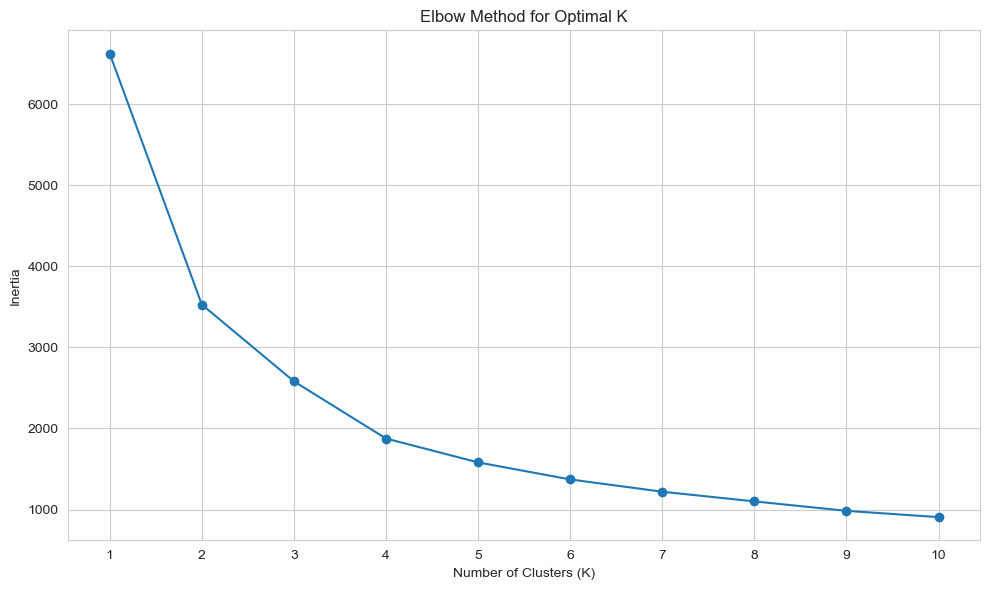

In [7]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [13]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

df['Cluster'].value_counts().sort_index()

Cluster
0    598
1    570
2    534
3    506
Name: count, dtype: int64

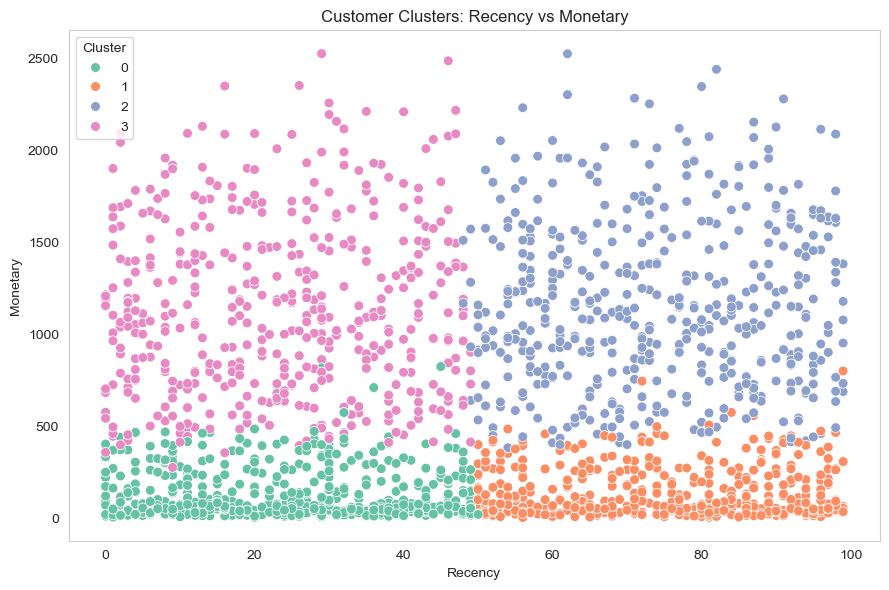

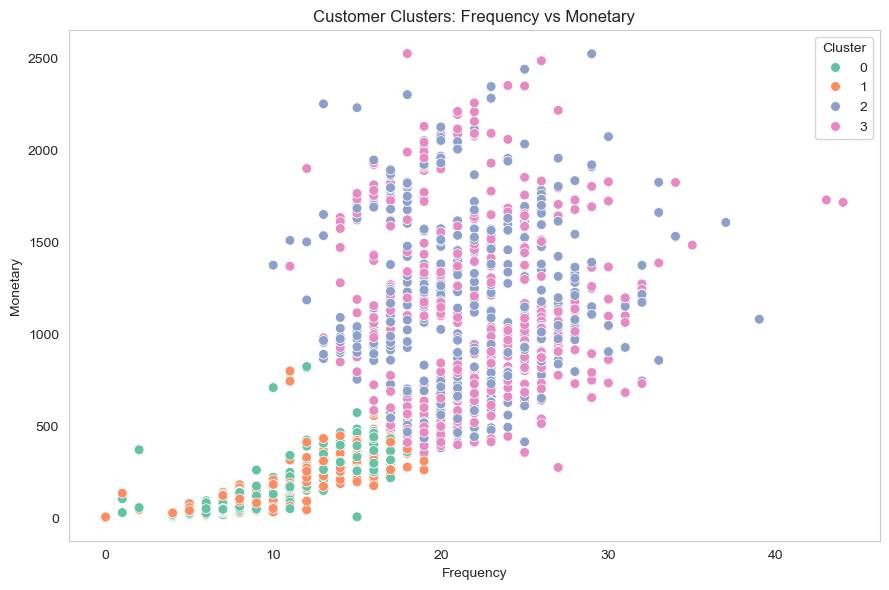

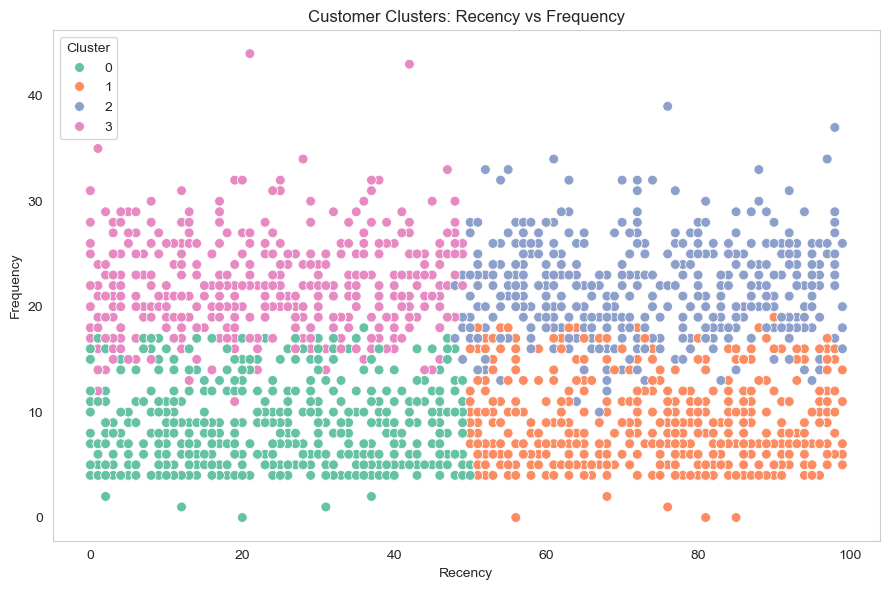

In [18]:
# Recency vs Monetary
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Recency', y='Monetary', hue='Cluster', palette='Set2', s=50)
plt.title("Customer Clusters: Recency vs Monetary")
plt.tight_layout()
plt.grid(False)
plt.show()

# Frequency vs Monetary
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', s=50)
plt.title("Customer Clusters: Frequency vs Monetary")
plt.tight_layout()
plt.grid(False)
plt.show()

# Recency vs Frequency
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Recency', y='Frequency', hue='Cluster', palette='Set2', s=50)
plt.title("Customer Clusters: Recency vs Frequency")
plt.tight_layout()
plt.grid(False)
plt.show()

In [15]:
cluster_profile = df.groupby('Cluster')[['Recency','Frequency','Monetary','AvgPurchaseValue','Age','Income']].mean()
cluster_profile['CustomerCount'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,Recency,Frequency,Monetary,AvgPurchaseValue,Age,Income,CustomerCount
Cluster,,,,,,,
0,24.51,8.64,128.28,12.79,42.72,36660.97,598
1,74.77,8.98,135.79,13.00,43.81,37354.46,570
2,73.32,21.51,1151.33,55.72,47.78,68615.01,534
3,23.51,21.92,1128.69,53.78,46.52,68845.02,506


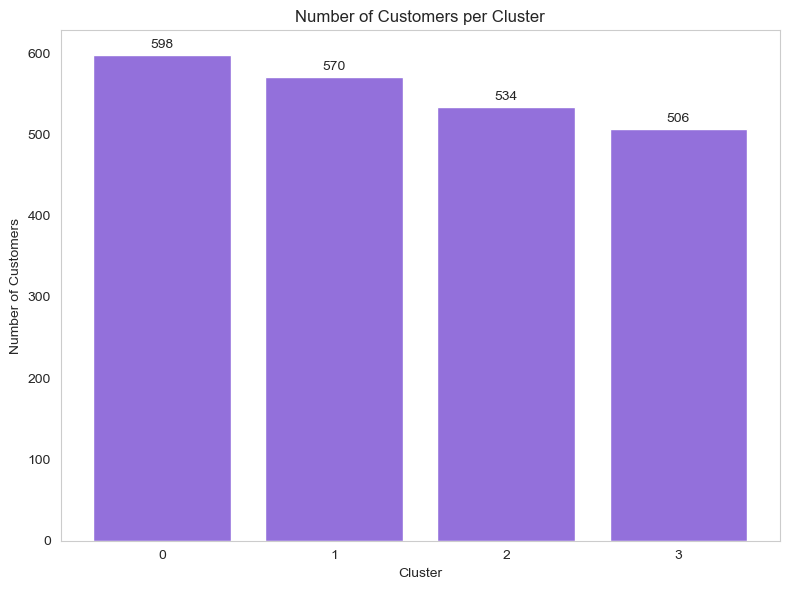

In [17]:
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,6))
bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color='mediumpurple')
plt.bar_label(bars, padding=3)
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.grid(False)
plt.show()

Cluster profiling: Clustering on Recency, Frequency, and Monetary (RFM) revealed four fairly evenly sized customer segments (23–27% of the base each). The clearest divide is between high-income (~$68.6K–$68.8K) and low-income (~$36.7K–$37.4K) customers, which corresponds almost exactly to high vs. low spend. Income appears to be the primary driver of purchase value, not age (which is fairly similar across all four clusters, 42.7–47.8). Within each income tier, customers split further by recency: Clusters 2 and 3 both spend heavily (~$1,130–$1,150 total, ~$54–56 per purchase) but Cluster 2 hasn't purchased in ~73 days on average vs. just ~24 days for Cluster 3 — meaning Cluster 2 represents high-value customers actively slipping away. The same recency split exists among low spenders (Clusters 0 and 1), though the stakes are much lower there.

## Customer Segment Insights & Recommendations

### Cluster 3 — Loyal Champions (506 customers, 22.6%)
High spend, high frequency, recently active. These are your best customers.
**Recommendation:** Reward and retain — VIP loyalty perks, early access to new products, referral incentives. Avoid heavy discounting here; focus on relationship-building since they're already converting well.

### Cluster 2 — At-Risk High-Value (534 customers, 23.8%)
High historical spend and frequency, but haven't purchased in ~73 days on average. This is the highest-priority segment.
**Recommendation:** Urgent, targeted win-back campaign — personalized re-engagement emails, a limited-time high-value offer, or a direct outreach/survey to understand why they've gone quiet. Losing this segment represents the largest revenue risk in the customer base.

### Cluster 1 — Disengaged Low-Value (570 customers, 25.4%)
Low spend, low frequency, and inactive for ~75 days on average.
**Recommendation:** Low-cost, automated re-engagement only (e.g. a generic "we miss you" email or small discount code). Not worth heavy investment given low historical value — deprioritize relative to Cluster 2.

### Cluster 0 — New/Casual Low-Spenders (598 customers, 26.6%)
Recently active but low frequency and low spend — the largest segment by size.
**Recommendation:** Nurture and grow — onboarding sequences, small first-purchase incentives, or cross-sell suggestions to increase purchase frequency. This segment has the most room for growth since they're already engaged, just not yet high-value.